# Capstone Black Box Project

## Function 5 - Chemical Process

black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 

## Submission 10 of 13

In [9]:
# Cell 1 - Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress
from plot_input_pairs import plot_nd_projection_matrix

## 1. Load Data

In [6]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_5"

def load_npy_files(function_name):
    inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return inputs, outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 29
[[1.   1.   1.   0.85]
 [1.   1.   1.   0.97]]
[6495.08188665 8115.43472314]


## 2. Describe and Review Data

In [7]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())


               0          1          2          3
count  29.000000  29.000000  29.000000  29.000000
mean    0.587135   0.619802   0.635417   0.607040
std     0.289660   0.305754   0.313812   0.330006
min     0.119879   0.038193   0.088947   0.072880
25%     0.355482   0.358510   0.378167   0.360342
50%     0.583973   0.667350   0.656000   0.759760
75%     0.836478   0.862540   0.964953   0.895234
max     1.000000   1.000000   1.000000   0.997529
                 0
count    29.000000
mean   1620.900795
std    2464.979027
min       0.112940
25%      45.181570
50%     109.571876
75%    2867.679218
max    8115.434723


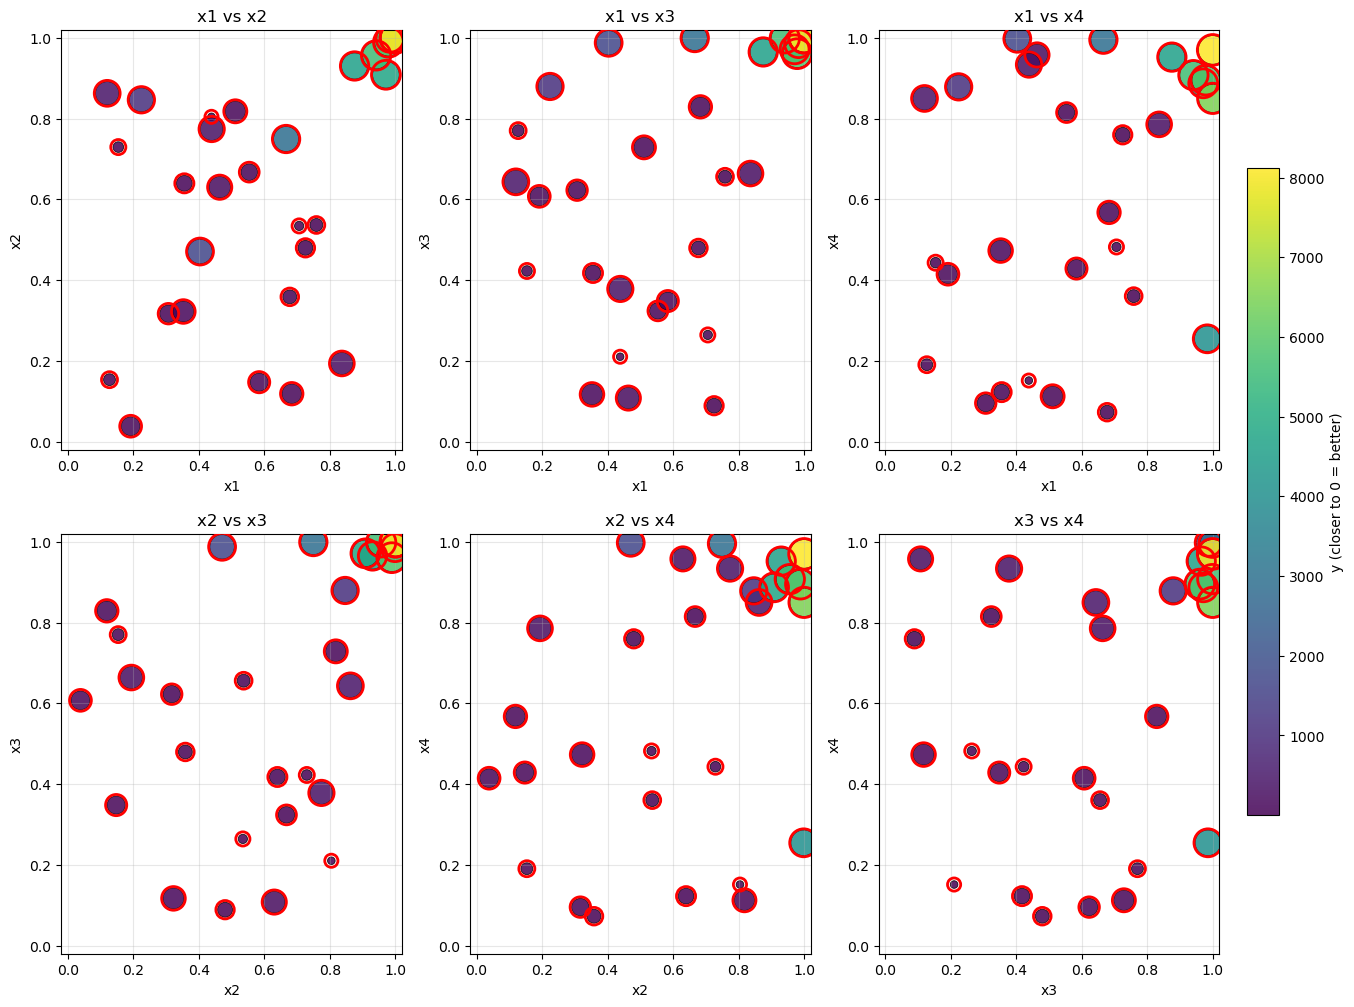

In [11]:
from scipy.stats import rankdata
from itertools import combinations

ridge_idx = np.where(y > 0)[0]   # or however you identify the ridge cluster
fig, axes = plot_nd_projection_matrix(X, y, highlight_idx=ridge_idx)
plt.savefig('./Figures/Function5_projection_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transform Data

In [12]:
# Wk 7 intriduced log transform
# log10 transform — y spans 4.7 orders of magnitude; raw-scale GP fit produced
# a 10-sigma miss on P26. All y strictly positive.
assert np.all(y > 0), "log transform requires positive y"
y_fit = np.log10(y)

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "X3": X[:,2],
    "X4": X[:,3],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./Data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_5 — y progression with running best'}, xlabel='Iteration (submission number)', ylabel='y'>)

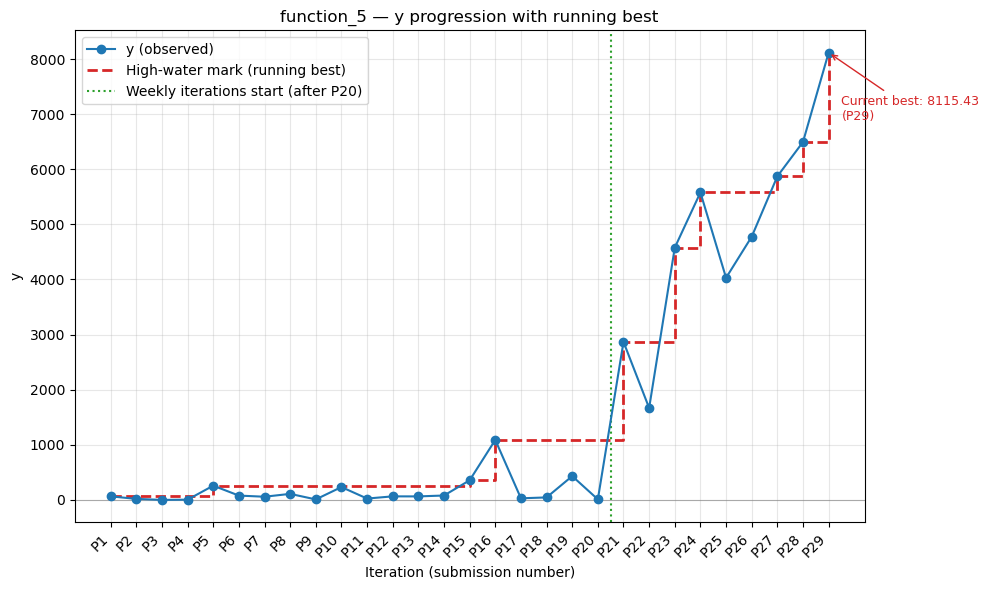

In [13]:
# Point labels and y values to monitor progress
# Plotting the untransformed values of y

plot_progress(y, labels=None, iteration_start=20, maximize=True,
                   objective_label="y", function_name=function,
                   save_path=None)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_5 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

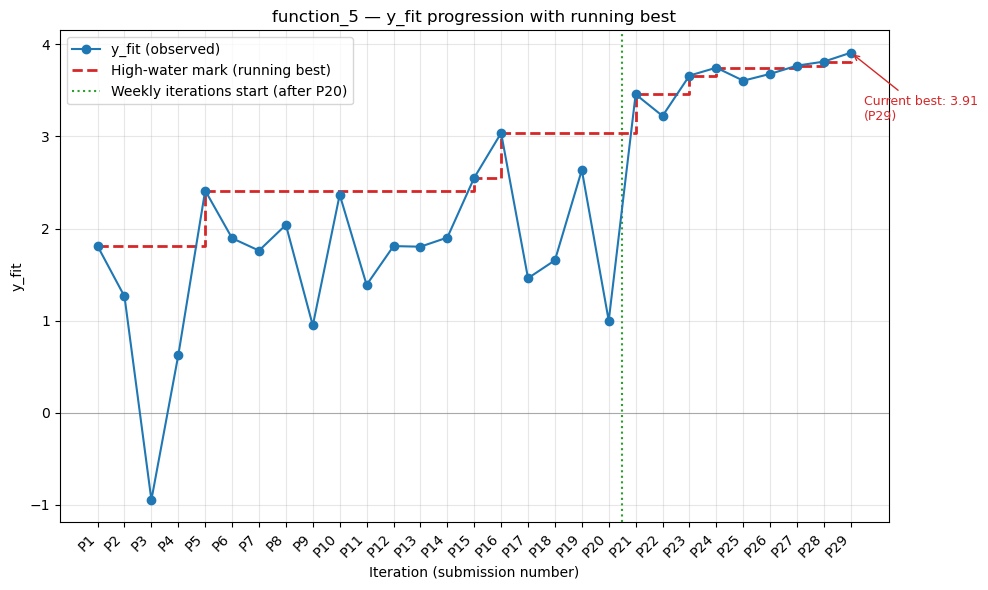

In [14]:
# Point labels and y values to monitor progress
# Plotting the transformed values of y_fit

plot_progress(y_fit, labels=None, iteration_start=20, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernal

In [15]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    # single scalar — isotropic
    'RBF1':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)), 
    'RBF2':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), 
    'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), 
    'RBF4':        ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    'RBF5':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]),length_scale_bounds=(0.05, 20.0)), #wk 3 onwards
    'RBF6':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(0.05, 2.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    pinned = "  [PINNED: " + "; ".join(str(warn.message).split(".")[0] for warn in w) + "]" if w else ""
    print(f"{name:18s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}{pinned}")

Matern_2.5          LML=-20.2575  AIC=44.5149  BIC=47.2495  kernel=1.44**2 * Matern(length_scale=0.732, nu=2.5)
Matern_1.5          LML=-21.1187  AIC=46.2375  BIC=48.9721  kernel=1.49**2 * Matern(length_scale=0.949, nu=1.5)
Matern_0.5          LML=-25.3388  AIC=54.6775  BIC=57.4121  kernel=1.25**2 * Matern(length_scale=1.84, nu=0.5)
RBF1                LML=-20.4881  AIC=44.9762  BIC=47.7108  kernel=1.28**2 * RBF(length_scale=0.48)
RBF2                LML=-20.4881  AIC=44.9762  BIC=47.7108  kernel=1.28**2 * RBF(length_scale=0.48)
RBF3                LML=-20.4881  AIC=44.9762  BIC=47.7108  kernel=1.28**2 * RBF(length_scale=0.48)
RBF4                LML=-20.5093  AIC=47.0186  BIC=51.1205  kernel=1.28**2 * RBF(length_scale=0.48) + WhiteKernel(noise_level=1e-05)  [PINNED: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05]
RBF5                LML=-13.3015  AIC=36.6030  BIC=43.4395  kernel=1.71**2 * RBF(length_scale=[1.35, 0.346, 

In [16]:
# Fit Gaussian Process
# Select the best kernel for fitting

kernel = kernels['RBF5']

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

1.71**2 * RBF(length_scale=[1.35, 0.346, 0.906, 0.633])
LML:       -13.3015


In [17]:
# Prediction Grid - Generate candidates and predict y

n_candidates = 10000
low = np.zeros(X.shape[1])
high = np.ones(X.shape[1])

rng = np.random.default_rng(42)
grid = rng.uniform(
low=low,
high=high,
size=(n_candidates, X.shape[1]))

print("Shape:", grid.shape)
print("Dimensions:", grid.ndim)
print("\nFirst 5 rows:")
print(grid[:5])
    
# GP predictions
mu, sigma = gpr.predict(grid, return_std=True)


Shape: (10000, 4)
Dimensions: 2

First 5 rows:
[[0.77395605 0.43887844 0.85859792 0.69736803]
 [0.09417735 0.97562235 0.7611397  0.78606431]
 [0.12811363 0.45038594 0.37079802 0.92676499]
 [0.64386512 0.82276161 0.4434142  0.22723872]
 [0.55458479 0.06381726 0.82763117 0.6316644 ]]


## 5. Define Acquisition Function

In [18]:
 
xi_values = {
    "function_5": 0.01,
}

In [19]:
# Expected Improvement acquisition function
y_best = np.max(y_fit)


xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = grid[next_idx]

print("Current best y:", y_best)
print("Current best y (log10):", y_best, "=> y =", 10**y_best)
print("Predicted mean (log10):", mu[next_idx], "=> y ~", 10**mu[next_idx])

print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.01 for function_5
Next Idx:  8249
Current best y: 3.909311788833231
Current best y (log10): 3.909311788833231 => y = 8115.434723142182
Predicted mean (log10): 3.50639529865205 => y ~ 3209.1890275749824
Next point to evaluate: [0.45012229 0.01836311 0.09550984 0.99188808]
Formatted next point to evaluate: 0.450122-0.018363-0.095510-0.991888
Expected improvement: 0.2644665710358253
Predicted mean: 3.50639529865205
Predicted std: 1.1041093772708357
Improvement: -0.4129164901811808


In [11]:
# UCB acquisition function

# ---- ACQUISITION: GP-UCB (replaces EI) ----
kappa = 10
ucb = mu + kappa * sigma
 
next_idx = np.argmax(ucb)
 
print(f"\nUsing kappa = {kappa} for function_5")
print("Next Idx: ", next_idx)
print("Current best y:", y_best)
print("Next point to evaluate:", grid[next_idx])
print("UCB value:", ucb[next_idx])
print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])


Using kappa = 10 for function_5
Next Idx:  6263
Current best y: 3.7465875379205364
Next point to evaluate: [0.50109855 0.0081099  0.00616334 0.94100933]
UCB value: 14.812756255506589
Predicted mean: 3.2187281050404737
Predicted std: 1.1594028150466116


In [20]:
# LHS local search (log-scale GP)
x_best = X[np.argmax(y)]
print("x_best index:", np.argmax(y))
r = 0.10

bounds_low  = np.array([max(0.0, x_best[i] - r) for i in range(4)])
bounds_high = np.array([min(1.0, x_best[i] + r) for i in range(4)])

sampler = LatinHypercube(d=4, seed=42)
lhs = sampler.random(n=50)
candidates = bounds_low + lhs * (bounds_high - bounds_low)

mu_c, _ = gpr.predict(candidates, return_std=True)

dmin = cdist(candidates, X).min(axis=1)
valid = dmin > 0.05

best_idx = np.argmax(mu_c[valid])
next_x = candidates[valid][best_idx]

print("r radius:", r)
print("Next point:", next_x)
print("Formatted:", "-".join(f"{x:.6f}" for x in next_x))
print("mu (log10):", mu_c[valid][best_idx], "=> y ~", 10**mu_c[valid][best_idx])
print(f"filter threshold in effect: candidates dropped = {(~valid).sum()}/{len(valid)}")
print(f"nearest candidate to P37: {cdist(candidates, X[[26]]).min():.4f}")

x_best index: 28
r radius: 0.1
Next point: [0.99066319 0.94105781 0.99286953 0.985011  ]
Formatted: 0.990663-0.941058-0.992870-0.985011
mu (log10): 3.8782148397197993 => y ~ 7554.658541814839
filter threshold in effect: candidates dropped = 12/50
nearest candidate to P37: 0.0350


In [12]:
# Boundary-slice search — GP favours x1=x2=1.0 exactly; LHS can't sample boundary faces
# Added week 8
g3 = np.linspace(0.85, 1.0, 61)
g4 = np.linspace(0.80, 1.0, 81)
G = np.array([[1.0, 1.0, a, b] for a in g3 for b in g4])
mu_g, sd_g = gpr.predict(G, return_std=True)

# Disciplined pick: fix x4=0.85 (edge of the validated-confidence regime; grid argmax
# drifts to x4=0.80 where sd doubles — extrapolation, defer until data supports it)
p28 = np.array([[1.0, 1.0, 1.0, 0.85]])
mu_p, sd_p = gpr.predict(p28, return_std=True)
print(f"P28 candidate: {p28[0]}")
print(f"mu_log={mu_p[0]:.4f} => y ~ {10**mu_p[0]:,.0f}, sd_log={sd_p[0]:.4f}")


P28 candidate: [1.   1.   1.   0.85]
mu_log=3.8126 => y ~ 6,495, sd_log=0.0000


In [21]:
#Wk 9 & wk 10
# x4 profile on the x1=x2=x3=1 edge, EXCLUDING evaluated neighbourhood
x4_grid = np.linspace(0.60, 1.00, 81)
G = np.column_stack([np.ones(81), np.ones(81), np.ones(81), x4_grid])
mu_g, sd_g = gpr.predict(G, return_std=True)          # log10 scale
y_g = 10**mu_g

for x4, m, s, yy in zip(x4_grid, mu_g, sd_g, y_g):
    if abs(x4 - 0.85) < 0.006:   # mark the P28 anchor
        print(f"x4={x4:.3f}  mu_log={m:.4f}  y~{yy:7.0f}  sd_log={s:.4f}  <- P28")
    elif x4 in (0.60,0.65,0.70,0.75,0.78,0.80,0.90,0.95,1.00) or abs(x4%0.05)<0.006:
        print(f"x4={x4:.3f}  mu_log={m:.4f}  y~{yy:7.0f}  sd_log={s:.4f}")

imax = int(np.argmax(mu_g))
print(f"\nSlice argmax: x4={x4_grid[imax]:.3f}  y~{y_g[imax]:.0f}  sd_log={sd_g[imax]:.4f}")

x4=0.600  mu_log=3.6348  y~   4313  sd_log=0.0792
x4=0.605  mu_log=3.6368  y~   4333  sd_log=0.0777
x4=0.650  mu_log=3.6590  y~   4560  sd_log=0.0632
x4=0.655  mu_log=3.6618  y~   4590  sd_log=0.0615
x4=0.700  mu_log=3.6906  y~   4905  sd_log=0.0452
x4=0.705  mu_log=3.6941  y~   4944  sd_log=0.0434
x4=0.750  mu_log=3.7281  y~   5346  sd_log=0.0273
x4=0.755  mu_log=3.7321  y~   5396  sd_log=0.0256
x4=0.780  mu_log=3.7526  y~   5657  sd_log=0.0175
x4=0.800  mu_log=3.7695  y~   5881  sd_log=0.0116
x4=0.805  mu_log=3.7737  y~   5939  sd_log=0.0102
x4=0.845  mu_log=3.8083  y~   6431  sd_log=0.0009  <- P28
x4=0.850  mu_log=3.8126  y~   6495  sd_log=0.0000  <- P28
x4=0.855  mu_log=3.8169  y~   6560  sd_log=0.0009  <- P28
x4=0.905  mu_log=3.8593  y~   7232  sd_log=0.0057
x4=0.950  mu_log=3.8948  y~   7849  sd_log=0.0033
x4=0.955  mu_log=3.8985  y~   7916  sd_log=0.0027
x4=1.000  mu_log=3.9292  y~   8496  sd_log=0.0079

Slice argmax: x4=1.000  y~8496  sd_log=0.0079


## 6. Plots for Uncertainty and Signal Strength 

In [ ]:
# --- Plot ---

